In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRFClassifier
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV   
import category_encoders as ce
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv(r"E:\computer science (Mostafa)\IEEE AI Task\IEEE-AI-Ambassadors-2026\Task_03\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [23]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
df = df.drop("customerID", axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [25]:
print(df.shape)
df["TotalCharges"] = pd.to_numeric( df["TotalCharges"], errors="coerce" ) 
df = df.dropna(subset=["TotalCharges"])  
print("\nDataset after cleaning:", df.shape)

(7043, 20)

Dataset after cleaning: (7032, 20)


## Mapping_Encoding  

In [26]:
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,1,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,0,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,0,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,1,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [27]:
col_yes_no = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in col_yes_no:
    df[col] = df[col].map({"Yes": 1, "No": 0})
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50,0
7039,0,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90,0
7040,0,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,1,1,1,0,4,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.60,1


## Ordinal Encoding

In [28]:
Ordinal_cols = df[["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]]
Ordinal_cols.head(26)
Ordinal_encoder = ce.OrdinalEncoder(cols=Ordinal_cols.columns)
Ordinal_encoder.fit(Ordinal_cols)   


,mapping,"[{'col': 'MultipleLines', 'data_type': <StringDtype(...na_value=nan)>, 'mapping': No phone serv...2 dtype: int64}, {'col': 'OnlineSecurity', 'data_type': <StringDtype(...na_value=nan)>, 'mapping': No ...2 dtype: int64}, ...]"
,cols,Index(['Multi... dtype='str')
,verbose,0
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,index_start,1
Name,Type,Value
feature_names_in_,list,"['Mu...es', 'On...ty', 'On...up', 'De...on', ...]"
feature_names_out_,"ndarray[object](7,)","['MultipleLines','OnlineSecurity','OnlineBackup',...,'TechSupport', 'StreamingTV','StreamingMovies']"


In [29]:
df = Ordinal_encoder.transform(Ordinal_cols).join(df.drop(columns=Ordinal_cols.columns))
df

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,1,1,1,1,1,1,0,0,1,0,1,0,DSL,Month-to-month,1,Electronic check,29.85,29.85,0
1,2,2,2,2,1,1,1,1,0,0,0,34,1,DSL,One year,0,Mailed check,56.95,1889.50,0
2,2,2,1,1,1,1,1,1,0,0,0,2,1,DSL,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,2,2,2,2,1,1,1,0,0,0,45,0,DSL,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,2,1,2,1,1,1,1,0,0,0,0,2,1,Fiber optic,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,3,2,2,2,2,2,2,1,0,1,1,24,1,DSL,One year,1,Mailed check,84.80,1990.50,0
7039,3,1,1,2,1,2,2,0,0,1,1,72,1,Fiber optic,One year,1,Credit card (automatic),103.20,7362.90,0
7040,1,2,2,1,1,1,1,0,0,1,1,11,0,DSL,Month-to-month,1,Electronic check,29.60,346.45,0
7041,3,1,2,1,1,1,1,1,1,1,0,4,1,Fiber optic,Month-to-month,1,Mailed check,74.40,306.60,1


### One Hot Encoding

In [30]:
en = df[["InternetService" , "Contract" , "PaymentMethod"]]
en.head(26)

,InternetService,Contract,PaymentMethod
0,DSL,Month-to-month,Electronic check
1,DSL,One year,Mailed check
2,DSL,Month-to-month,Mailed check
3,DSL,One year,Bank transfer (automatic)
4,Fiber optic,Month-to-month,Electronic check
5,Fiber optic,Month-to-month,Electronic check
6,Fiber optic,Month-to-month,Credit card (automatic)
7,DSL,Month-to-month,Mailed check
8,Fiber optic,Month-to-month,Electronic check
9,DSL,One year,Bank transfer (automatic)


In [31]:
encoder = ce.OneHotEncoder(cols=en.columns)
encoder.fit(en)
df = encoder.transform(en).join(df.drop(columns=en.columns))
df

,InternetService_1,InternetService_2,InternetService_3,Contract_1,Contract_2,Contract_3,PaymentMethod_1,PaymentMethod_2,PaymentMethod_3,PaymentMethod_4,...,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,1,0,0,1,0,0,1,0,0,0,...,0,0,1,0,1,0,1,29.85,29.85,0
1,1,0,0,0,1,0,0,1,0,0,...,1,0,0,0,34,1,0,56.95,1889.50,0
2,1,0,0,1,0,0,0,1,0,0,...,1,0,0,0,2,1,1,53.85,108.15,1
3,1,0,0,0,1,0,0,0,1,0,...,1,0,0,0,45,0,0,42.30,1840.75,0
4,0,1,0,1,0,0,1,0,0,0,...,0,0,0,0,2,1,1,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,0,1,0,0,1,0,0,...,1,0,1,1,24,1,1,84.80,1990.50,0
7039,0,1,0,0,1,0,0,0,0,1,...,0,0,1,1,72,1,1,103.20,7362.90,0
7040,1,0,0,1,0,0,1,0,0,0,...,0,0,1,1,11,0,1,29.60,346.45,0
7041,0,1,0,1,0,0,0,1,0,0,...,1,1,1,0,4,1,1,74.40,306.60,1


In [32]:
x = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)
numeric_features = x.select_dtypes( include=["int64", "float64"] ).columns.tolist() 
categorical_features = x.select_dtypes( include=["object"] ).columns.tolist()
print("\nNumerical features:") 
print(numeric_features) 
print("\nCategorical features:") 
print(categorical_features)


Numerical features:
['InternetService_1', 'InternetService_2', 'InternetService_3', 'Contract_1', 'Contract_2', 'Contract_3', 'PaymentMethod_1', 'PaymentMethod_2', 'PaymentMethod_3', 'PaymentMethod_4', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']

Categorical features:
[]


In [33]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].astype(str).str.strip(), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 ,  stratify=y)


In [34]:
sc_x = StandardScaler()
x_train_sc = sc_x.fit_transform(x_train)
x_test_sc = sc_x.transform(x_test)

In [35]:
model = LogisticRegression()
model.fit(x_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [36]:
model.coef_

array([[-0.01395899,  0.55730978, -0.6577473 ,  0.32063816, -0.04927395,
        -0.32595361,  0.11376762, -0.02732083, -0.06049961, -0.04227118,
         0.23961448, -0.29326222,  0.08961554,  0.06300839, -0.25458796,
         0.29206491,  0.27175447, -0.01216765,  0.07126754, -0.01306806,
        -0.10512117, -1.34541298, -0.20863981,  0.14306087, -0.4737217 ,
         0.63909491]])

In [37]:
model.predict(x_test_sc)

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

## Evaluation Matrix

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



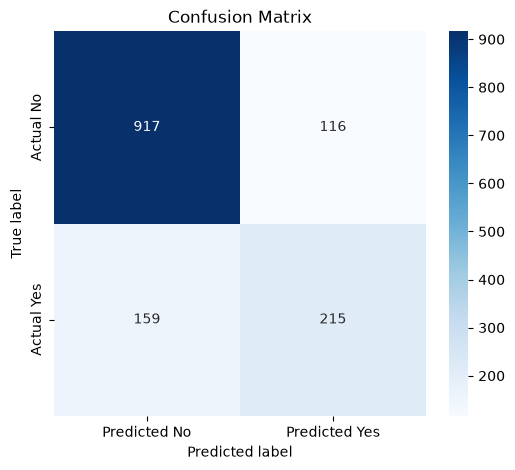

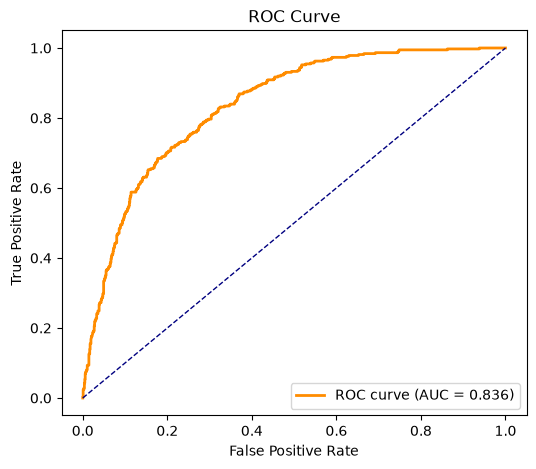

In [38]:
y_pred = model.predict(x_test_sc)
y_prob = model.predict_proba(x_test_sc)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


In [ ]:

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Train baseline XGBoost with default hyperparameters
xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
xgb_baseline.fit(x_train, y_train)

print("=" * 60)
print("Baseline XGBoost Model trained with default hyperparameters")
print("=" * 60)
print("\nDefault Parameters:")
baseline_params = xgb_baseline.get_params()
for key, value in sorted(baseline_params.items()):
    if key in ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree']:
        print(f"  {key}: {value}")

Baseline XGBoost Model trained with default hyperparameters

Default Parameters:
  colsample_bytree: None
  learning_rate: None
  max_depth: None
  n_estimators: None
  subsample: None


In [40]:
# Baseline Model Predictions
y_pred_baseline = xgb_baseline.predict(x_test)
y_prob_baseline = xgb_baseline.predict_proba(x_test)[:, 1]

print("\nBaseline XGBoost Predictions generated on test set")
print(f"Predictions shape: {y_pred_baseline.shape}")
print(f"Probabilities shape: {y_prob_baseline.shape}")


Baseline XGBoost Predictions generated on test set
Predictions shape: (1407,)
Probabilities shape: (1407,)


In [41]:
# ============================================
# XGBoost Hyperparameter Tuning
# ============================================
from scipy.stats import randint, uniform

# Define hyperparameter grid for RandomizedSearchCV
param_dist = {
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': randint(50, 300),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

# Initialize RandomizedSearchCV
xgb_tuned = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
random_search = RandomizedSearchCV(
    xgb_tuned, 
    param_distributions=param_dist, 
    n_iter=20,  # Number of combinations to try
    cv=5, 
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("=" * 60)
print("Starting Hyperparameter Tuning with RandomizedSearchCV")
print("=" * 60)
print(f"Total combinations to evaluate: 20")
print(f"Cross-validation folds: 5")

# Fit the random search
random_search.fit(x_train, y_train)

print("\n" + "=" * 60)
print("Tuning Complete!")
print("=" * 60)
print(f"\nBest CV Score (ROC-AUC): {random_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")

# Get the best model
xgb_best = random_search.best_estimator_
print("\nBest XGBoost model fitted and ready for evaluation")

Starting Hyperparameter Tuning with RandomizedSearchCV
Total combinations to evaluate: 20
Cross-validation folds: 5
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning Complete!

Best CV Score (ROC-AUC): 0.8494

Best Hyperparameters:
  colsample_bytree: 0.5704621124873813
  gamma: 4.010984903770199
  learning_rate: 0.032365193103931246
  max_depth: 9
  min_child_weight: 9
  n_estimators: 137
  subsample: 0.6974407590877849

Best XGBoost model fitted and ready for evaluation


In [42]:
# Tuned Model Predictions
y_pred_tuned = xgb_best.predict(x_test)
y_prob_tuned = xgb_best.predict_proba(x_test)[:, 1]

print("Tuned XGBoost Predictions generated on test set")
print(f"Predictions shape: {y_pred_tuned.shape}")
print(f"Probabilities shape: {y_prob_tuned.shape}")

Tuned XGBoost Predictions generated on test set
Predictions shape: (1407,)
Probabilities shape: (1407,)


In [43]:
# ============================================
# Model Evaluation: Baseline vs Tuned
# ============================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Calculate evaluation metrics for both models
metrics_baseline = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline),
    'Recall': recall_score(y_test, y_pred_baseline),
    'F1-Score': f1_score(y_test, y_pred_baseline),
    'ROC-AUC': roc_auc_score(y_test, y_prob_baseline)
}

metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned)
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Baseline XGBoost': metrics_baseline,
    'Tuned XGBoost': metrics_tuned
})

comparison_df['Improvement'] = comparison_df['Tuned XGBoost'] - comparison_df['Baseline XGBoost']

print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.round(4))

print("\n" + "=" * 80)
print("IMPROVEMENT SUMMARY")
print("=" * 80)
for metric, improvement in comparison_df['Improvement'].items():
    direction = "↑ Improved" if improvement > 0 else "↓ Declined" if improvement < 0 else "→ Same"
    print(f"{metric:12s}: {improvement:+.4f}  {direction}")


MODEL PERFORMANCE COMPARISON
           Baseline XGBoost  Tuned XGBoost  Improvement
Accuracy             0.7726         0.7996       0.0270
Precision            0.5804         0.6474       0.0671
Recall               0.5214         0.5401       0.0187
F1-Score             0.5493         0.5889       0.0396
ROC-AUC              0.8098         0.8405       0.0307

IMPROVEMENT SUMMARY
Accuracy    : +0.0270  ↑ Improved
Precision   : +0.0671  ↑ Improved
Recall      : +0.0187  ↑ Improved
F1-Score    : +0.0396  ↑ Improved
ROC-AUC     : +0.0307  ↑ Improved


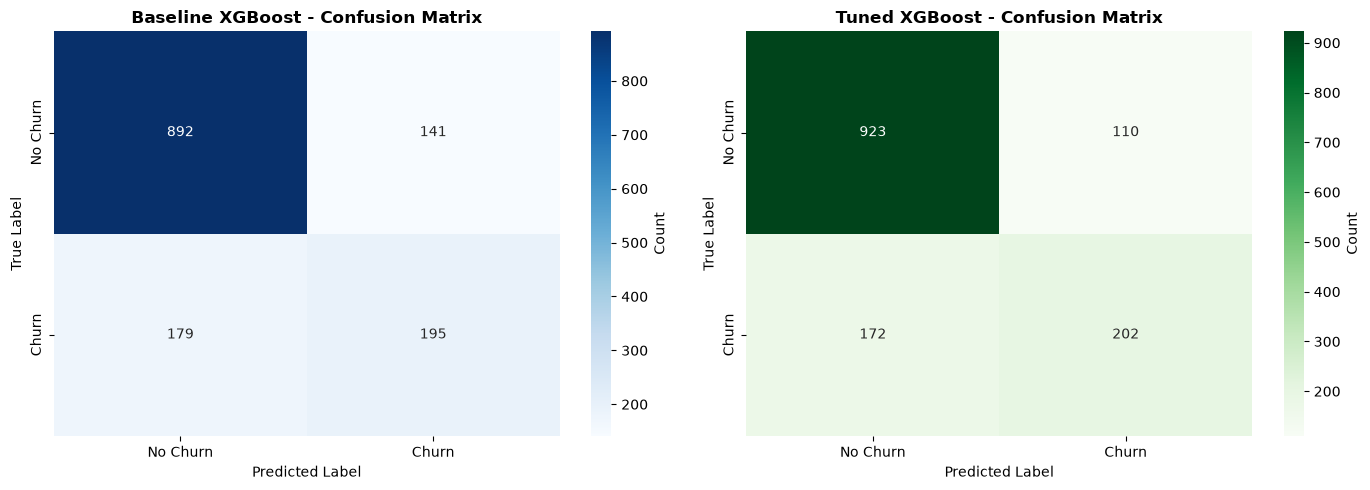


Confusion Matrices plotted successfully


In [44]:
# Confusion Matrices
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Confusion Matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Baseline XGBoost - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Tuned Confusion Matrix
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Tuned XGBoost - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("\nConfusion Matrices plotted successfully")

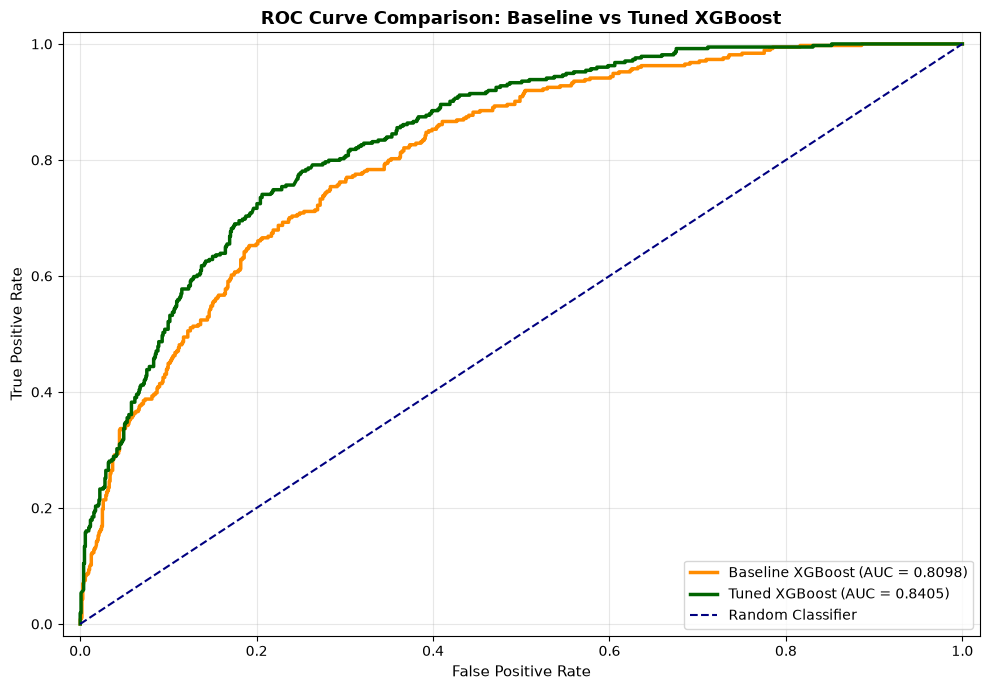

Baseline XGBoost ROC-AUC: 0.8098
Tuned XGBoost ROC-AUC: 0.8405
AUC Improvement: +0.0307


In [ ]:
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_prob_baseline)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(10, 7))
plt.plot(fpr_baseline, tpr_baseline, color='darkorange', lw=2.5, 
         label=f'Baseline XGBoost (AUC = {roc_auc_baseline:.4f})')
plt.plot(fpr_tuned, tpr_tuned, color='darkgreen', lw=2.5, 
         label=f'Tuned XGBoost (AUC = {roc_auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve Comparison: Baseline vs Tuned XGBoost', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Baseline XGBoost ROC-AUC: {roc_auc_baseline:.4f}")
print(f"Tuned XGBoost ROC-AUC: {roc_auc_tuned:.4f}")
print(f"AUC Improvement: {roc_auc_tuned - roc_auc_baseline:+.4f}")